# Heart Disease Prediction - Exploratory Data Analysis (EDA)

This notebook focuses on understanding the UCI Heart Disease dataset, analyzing its features, and preparing it for machine learning modeling.

## Step 2: Import Libraries

**What & Why:**
- **What:** Imported data manipulation libraries (`pandas`, `numpy`) and visualization libraries (`matplotlib.pyplot`, `seaborn`).
- **Why:** To load, inspect, clean, and visualize the data in preparation for modeling.

In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## Step 3: Load the Dataset

**What & Why:**
- **What:** Read the raw CSV file (`heart_disease_uci.csv`) into a Pandas DataFrame.
- **Why:** To make the dataset available in our active Python session for analysis.

In [73]:
df = pd.read_csv("../data/heart_disease_uci.csv")

## Step 4: Display the Dataset

**What & Why:**
- **What:** Printed the top, bottom, and random rows of the dataset.
- **Why:** To visually inspect column formats, value ranges, categorical vs. numerical representations, and confirm the data loaded correctly.

In [74]:
# First 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [75]:
# Last 5 rows
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [76]:
# Random 5 rows
df.sample(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
502,503,41,Male,Hungary,asymptomatic,120.0,237.0,NaN,normal,138.0,True,1.0,flat,NaN,NaN,1
557,558,44,Male,Hungary,asymptomatic,130.0,290.0,False,normal,100.0,True,2.0,flat,NaN,NaN,1
233,234,74,Female,Cleveland,atypical angina,120.0,269.0,False,lv hypertrophy,121.0,True,0.2,upsloping,1.0,normal,0
864,865,54,Male,VA Long Beach,non-anginal,NaN,203.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
328,329,37,Male,Hungary,asymptomatic,120.0,223.0,False,normal,168.0,False,0.0,NaN,NaN,normal,0


## Step 5: Understand the Dataset

**What, Why & Observations:**
- **What:** Inspected the overall shape (`df.shape`), column names, and data types (`df.info()`).
- **Why:** To understand the dimensions of the data (number of patient records and features) and identify numerical vs. categorical variables.
- **Observations:** There are 920 patients and 16 columns. There is a mix of `float64`, `int64`, and `object` (string categorical) columns.

In [77]:
# Shape of the dataset
df.shape

(920, 16)

In [78]:
# Column names
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [79]:
# General dataset information (missing values count, data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## Step 6: Check Missing Values

**What, Why & Observations:**
- **What:** Checked missing value counts per column and created a heatmap visualization.
- **Why:** Identifying missing data early is crucial because standard machine learning algorithms cannot handle null inputs, and this informs our imputation strategy.
- **Observations:** Columns like `ca` (611 missing), `thal` (486 missing), and `slope` (309 missing) have high proportions of missing values, which will require careful handling.

In [80]:
# Count of missing values per column
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

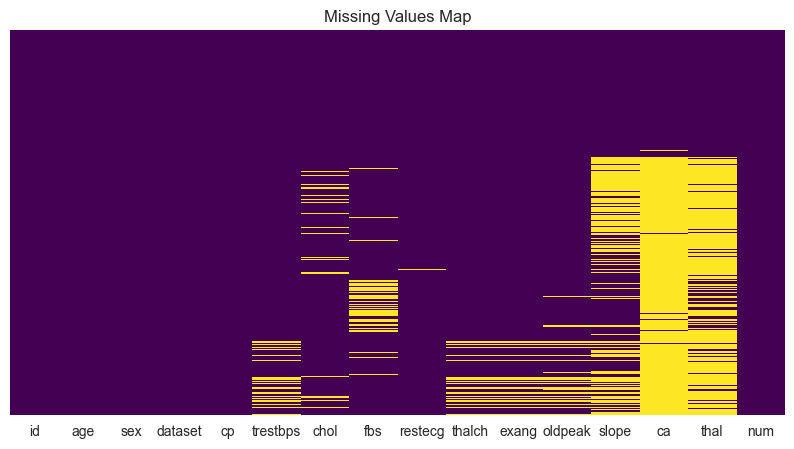

In [81]:
# Heatmap visualization of missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Map")
plt.show()

## Step 7: Basic Statistics

**What, Why & Observations:**
- **What:** Generated statistical summaries for numerical (`describe`) and categorical (`describe(include="object")`) columns.
- **Why:** To understand the mean, variance, ranges, and frequencies of features, helping identify potential scale imbalances or data entry anomalies.
- **Observations:** The average age of patients is 53.5 years. Min/Max values show that some features (e.g., resting blood pressure `trestbps`) contain high extremes (up to 200).

In [82]:
# Summary statistics for numerical columns
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [83]:
# Summary statistics for categorical columns
df.describe(include="object")

,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


## Step 8: Check Duplicate Rows

**What & Why:**
- **What:** Summed the count of identical duplicate rows in the dataset.
- **Why:** Duplicate records inflate training performance metrics falsely and do not add new information, so they must be removed if found.

In [84]:
# Check for duplicated rows
df.duplicated().sum()

np.int64(0)

## Step 9: Target Variable

**What, Why & Observations:**
- **What:** Checked class counts for original severity column (`num`) and converted it to a binary classification indicator (`target`).
- **Why:** The raw target `num` measures severity from 0 (healthy) to 4. For standard binary prediction (healthy vs. heart disease), we group values 1-4 into a single 'Disease' class (`1`).
- **Observations:** Grouping raw values results in 509 patients with disease and 411 healthy patients.

In [85]:
# Inspecting the raw target variable (num)
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [86]:
# Convert to binary target (0 = no disease, 1 = disease)
df["target"] = (df["num"] > 0).astype(int)

In [87]:
# Check counts for binary target
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

## Step 10: Drop Unnecessary Columns

**What & Why:**
- **What:** Dropped the `id`, `dataset` (source origin), and `num` (original target) columns.
- **Why:** Removing identifiers and original target levels prevents data leakage during training, and removes attributes that are clinically irrelevant for predictive modeling.

In [88]:
# Drop identifier, database origin, and original raw target columns
df = df.drop(columns=["id", "dataset", "num"])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Step 11: Target Distribution

**What, Why & Observations:**
- **What:** Plotted the count distribution of the final binary `target` column.
- **Why:** Checking class balance helps verify if we need techniques like oversampling/undersampling, or specialized classification metrics.
- **Observations:** The target distribution is balanced (55.3% diseased vs. 44.7% healthy), meaning standard accuracy remains a valid evaluation metric.

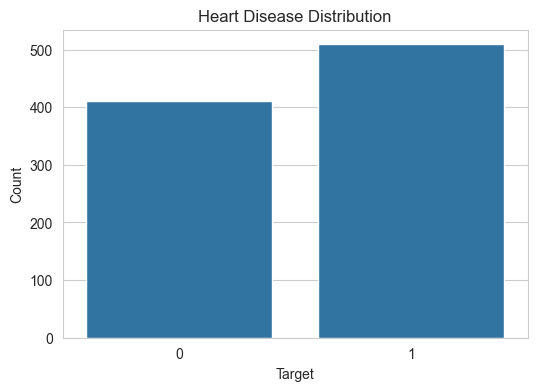

In [89]:
# Plot the distribution of the binary target variable
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target")
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## Step 12: Numerical Feature Distribution

**What, Why & Observations:**
- **What:** Plotted histograms for all numerical clinical measurements.
- **Why:** Helps identify skewed variables (which might benefit from logarithmic transforms) and visualizes potential outlier ranges.
- **Observations:** `oldpeak` (ST depression) is highly right-skewed. The cholesterol (`chol`) distribution has a notable spike at `0.0`, representing clinically missing value recordings.

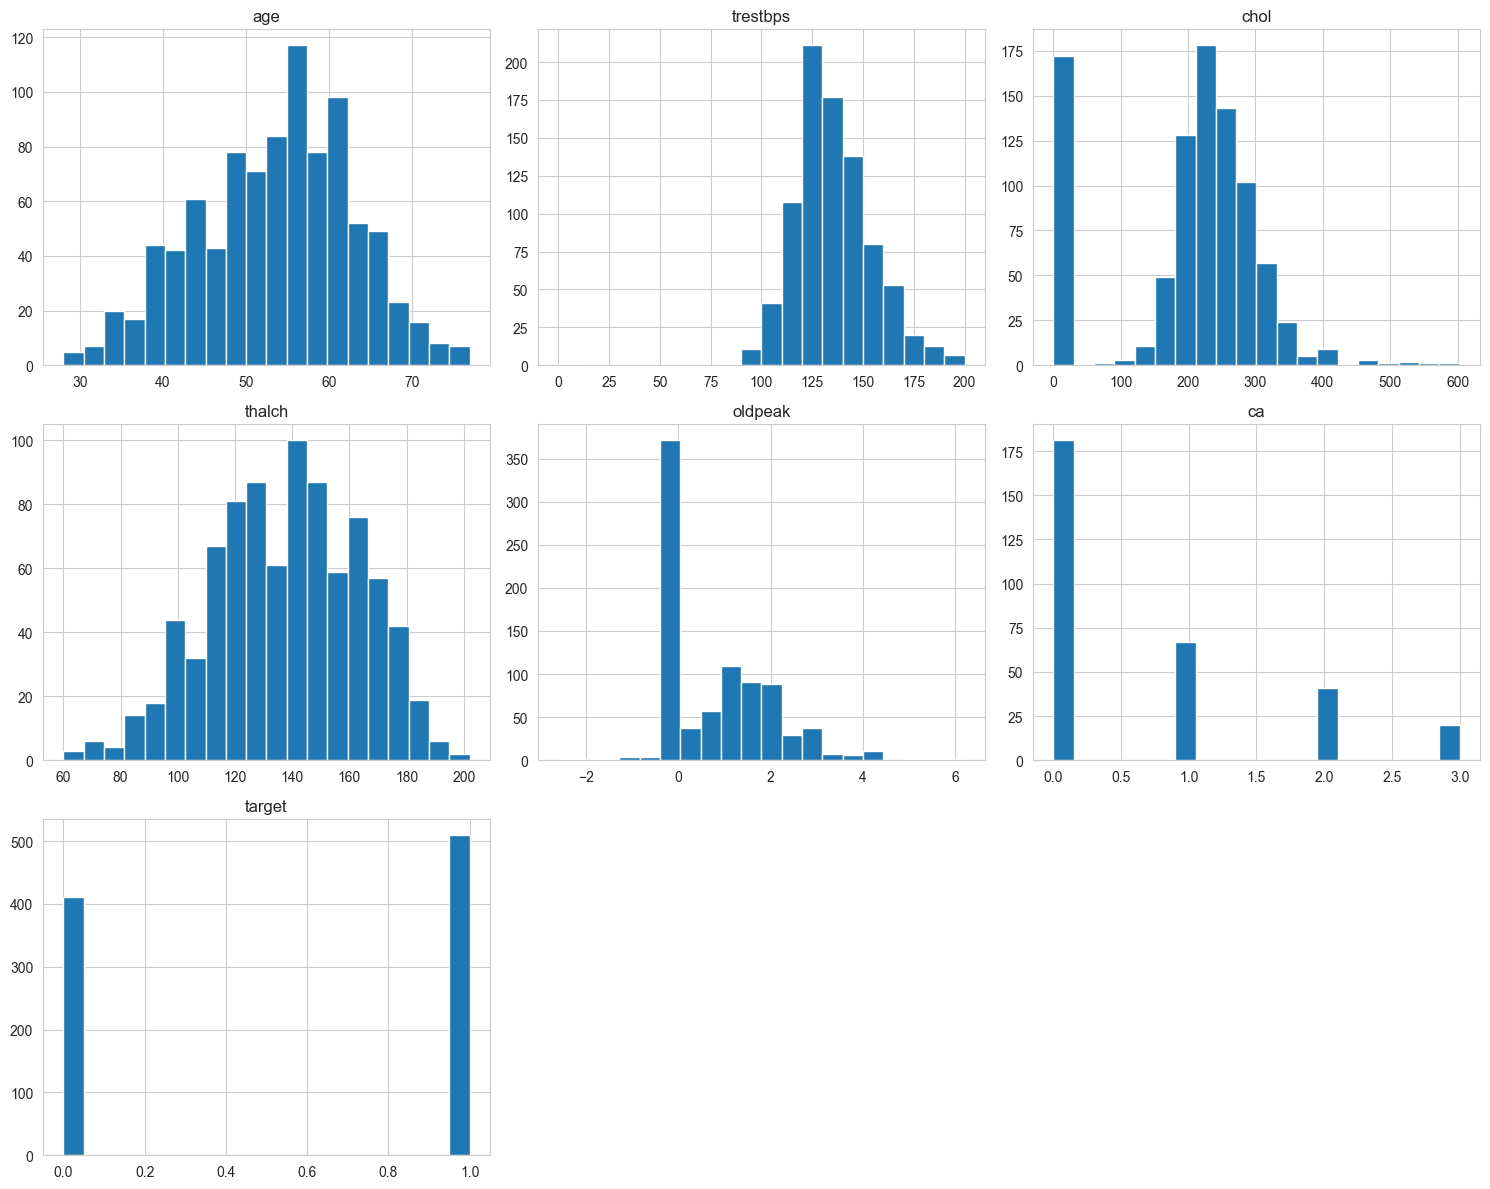

In [90]:
# Plot histograms for all numerical features
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

## Step 13: Correlation Matrix

**What, Why & Observations:**
- **What:** Computed Pearson correlation coefficients and plotted them as a heatmap.
- **Why:** To identify which variables are most strongly related to the heart disease target, and check for multicollinearity (redundant features correlated with each other).
- **Observations:** `ca` (0.46) and `oldpeak` (0.39) show positive correlations with the target. `thalach` (max heart rate) shows a negative correlation (-0.39).

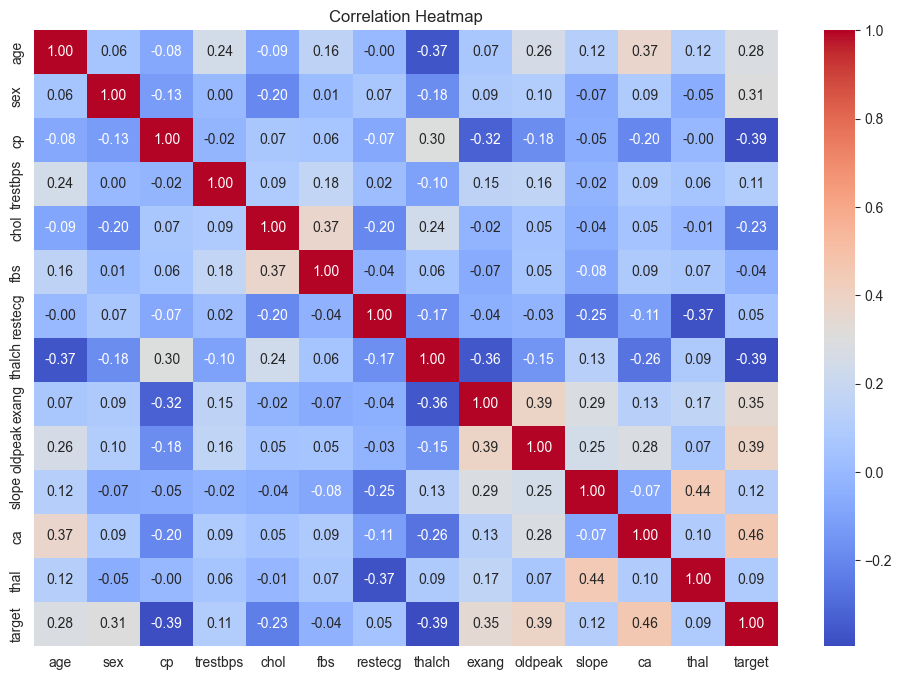

In [91]:
# Convert categorical columns to numeric codes temporarily for correlation matrix
df_corr = df.copy()
for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

# Compute correlation matrix
corr = df_corr.corr(numeric_only=True)

# Visualize correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

## Step 14: Pairplot (Optional)

**What & Why:**
- **What:** Plotted a bivariate pairplot focusing on key clinical numeric features (`age`, `trestbps`, `chol`, `thalch`) colored by class.
- **Why:** To visually inspect overlapping distributions and check if classes separate clearly across feature combinations.

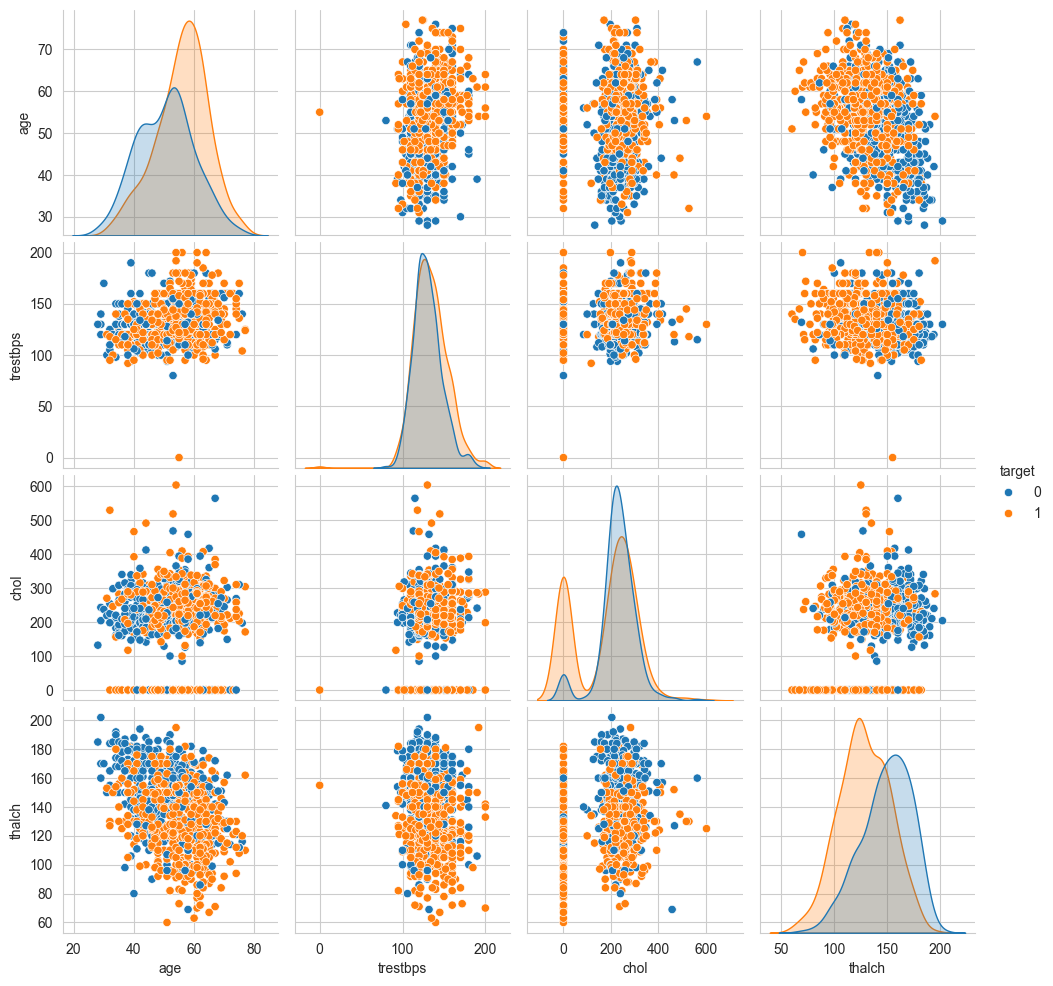

In [92]:
# Pairplot of key clinical numerical features colored by target
sns.pairplot(
    df,
    vars=["age", "trestbps", "chol", "thalch"],
    hue="target"
)
plt.show()

## Step 15: Save Your Progress

**What & Why:**
- **What:** Saved the cleaned dataset to `data/heart_clean_day1.csv`.
- **Why:** To persist our clean, binary-labeled dataset to disk so it's ready for training and scaling tasks.

In [93]:
# Save the clean dataset to a new CSV file
df.to_csv("../data/heart_clean_day1.csv", index=False)

## 📝 End-of-Day Questions & Answers

**1. How many patients are in the dataset?**
- There are **920 patients** in total (shape: `(920, 16)`).

**2. How many features remain after dropping unnecessary columns?**
- **13 features** remain (along with the 1 binary `target` column, totaling 14 columns).

**3. Are there missing values? Which columns?**
- Yes, there are significant missing values:
  - `trestbps` (59 missing)
  - `chol` (30 missing)
  - `fbs` (90 missing)
  - `restecg` (2 missing)
  - `thalach` (55 missing)
  - `exang` (55 missing)
  - `oldpeak` (62 missing)
  - `slope` (309 missing)
  - `ca` (611 missing)
  - `thal` (486 missing)

**4. Is the dataset balanced?**
- Yes, it is relatively balanced: **509 patients** (55.3%) have heart disease (`target = 1`), and **411 patients** (44.7%) are healthy (`target = 0`).

**5. Which feature has the strongest correlation with the target?**
- `ca` (colored major vessels) has the highest positive correlation with `target` (**0.46**).
- `thalach` (max heart rate) and `cp` (chest pain type) have the strongest negative correlation (**-0.39**).

**6. Which features appear to be the most useful for prediction?**
- Based on correlations: `ca` (0.46), `thalach` (-0.39), `cp` (-0.39), `oldpeak` (0.39), `exang` (0.35), and `sex` (0.31).

**7. Did you observe any outliers or unusual distributions?**
- **Cholesterol 0-values**: The `chol` column contains multiple `0` entries which represent missing values recorded as zero rather than clinical zeroes, producing a bi-modal distribution skew.
- **Skewness**: `oldpeak` is highly right-skewed.
- **Outliers**: There are extreme values in `trestbps` (>180) and `chol` (>500).